In [ ]:
# run before everything
%cd nn

In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets

import src.utils.datasets as utils

%matplotlib inline 

## Datasets

In [35]:
transform = utils.create_transform()

train_ds = utils.load_torchvision_dataset(datasets.MNIST, train=True, transform=transform)
test_ds = utils.load_torchvision_dataset(datasets.MNIST, train=False, transform=transform)

In [4]:
def stack_dataset_images(dataset) -> torch.Tensor:
    return torch.stack([dataset[i][0] for i in range(len(dataset))])    

In [ ]:
train_6_ds = utils.filter_dataset_by_classes(train_ds, target_classes=(6,))
train_7_ds = utils.filter_dataset_by_classes(train_ds, target_classes=(7,))

train_s_6 = stack_dataset_images(train_6_ds).float().squeeze(1)
train_s_7 = stack_dataset_images(train_7_ds).float().squeeze(1)

test_6_ds = utils.filter_dataset_by_classes(test_ds, target_classes=(6,))
test_7_ds = utils.filter_dataset_by_classes(test_ds, target_classes=(7,))

valid_s_6 = stack_dataset_images(test_6_ds).float().squeeze(1)
valid_s_7 = stack_dataset_images(test_7_ds).float().squeeze(1)


# train_s_6 /= 255.0
# train_s_7 /= 255.0

# valid_s_6 /= 255.0
# valid_s_7 /= 255.0
# print(train_s_6.min(), train_s_6.max())


tensor(-1.) tensor(1.)


In [66]:
train_x = torch.cat([train_s_6, train_s_7]).view(-1, 28*28)
train_y = torch.tensor([1]*len(train_s_6) + [0]*len(train_s_7)).unsqueeze(1)

In [67]:
valid_x = torch.cat([valid_s_6, valid_s_7]).view(-1, 28*28)
valid_y = torch.tensor([1]*len(valid_s_6) + [0]*len(valid_s_7)).unsqueeze(1)

In [68]:
train_ds = list(zip(train_x, train_y))
valid_ds = list(zip(valid_x,valid_y))

`shuffle=True` because it can't learn fast when data in order.

In [ ]:
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True) # Shuffle helps
valid_dl = DataLoader(valid_ds, batch_size=256)

In [13]:
xb, yb = next(iter(train_dl))
xb.shape,yb.shape

(torch.Size([256, 784]), torch.Size([256, 1]))

In [14]:
xb, yb = next(iter(valid_dl))
xb.shape,yb.shape

(torch.Size([256, 784]), torch.Size([256, 1]))

### functions

In [9]:
def init_params(size, std=1.0): return (torch.randn(size)*std).requires_grad_()

In [10]:
def linear1(xb): return xb@weights + bias

In [15]:
def calc_grad(xb, yb, model):
    preds = model(xb)
    loss = mnist_loss(preds, yb)
    loss.backward()

In [11]:
def mnist_loss(predictions, targets):
    predictions = predictions.sigmoid()
    return torch.where(targets==1, 1-predictions, predictions).mean()

In [16]:
def train_epoch(model, dl, lr, params):
    for xb,yb in dl:
        calc_grad(xb, yb, model)
        for p in params:
            p.data -= p.grad*lr
            p.grad.zero_()

In [17]:
def batch_accuracy(xb, yb):
    preds = xb.sigmoid()
    correct = (preds>0.5) == yb
    return correct.float().mean()

In [18]:
def validate_epoch(model, valid_dl):
    accs = [batch_accuracy(model(xb), yb) for xb,yb in valid_dl]
    return round(torch.stack(accs).mean().item(), 4)

## Manual version

In [19]:
weights = init_params((28*28,1))
bias = init_params(1)

In [20]:
lr = 1
params = weights,bias
train_epoch(linear1, train_dl, lr, params)
validate_epoch(linear1, valid_dl)

0.5322

In [21]:
for i in range(20):
    train_epoch(linear1, train_dl, lr, params)
    print(validate_epoch(linear1, valid_dl), end=" ")

0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 

## torch version

In [58]:
linear_model = nn.Linear(28*28,1)
w,b = linear_model.parameters()
w.shape,b.shape

(torch.Size([1, 784]), torch.Size([1]))

In [59]:
lr = 1
opt = torch.optim.SGD(linear_model.parameters(), lr=lr)

In [45]:
def train_epoch(model, dl):
    for xb, yb in dl:
        calc_grad(xb, yb, model)
        opt.step()
        opt.zero_grad()

In [29]:
validate_epoch(linear_model, valid_dl)

0.4678

In [46]:
for i in range(20):
    train_epoch(linear_model, train_dl)
    print(validate_epoch(linear_model, valid_dl), end=" ")

0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 0.5322 

In [37]:
print(linear_model.weight.grad)
print(linear_model.weight[0, :5])

None
tensor([-0.0489, -0.0142, -0.0662, -0.0747, -0.0098], grad_fn=<SliceBackward0>)


In [ ]:
def train_epoch(model, dl):
    total_loss = 0
    for xb, yb in dl:
        preds = model(xb)
        loss = mnist_loss(preds, yb)
        loss.backward()
        opt.step()
        opt.zero_grad()
        total_loss += loss.item()
    return total_loss

for i in range(100):
    l = train_epoch(linear_model, train_dl)
    print(l, validate_epoch(linear_model, valid_dl))

In [ ]:
preds = linear_model(valid_x).sigmoid()
print(preds.min().item(), preds.max().item(), preds.mean().item())

In [70]:
linear_model = nn.Linear(28*28, 1)
opt = torch.optim.SGD(linear_model.parameters(), lr=0.1, momentum=0.9)

# ☝️ Linear binary classifier

In [80]:
in_p = train_ds[0][0].shape[0]
in_p

784

In [92]:
model = nn.Sequential(
    nn.Linear(in_p, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)
model

Sequential(
  (0): Linear(in_features=784, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=1, bias=True)
)

8.952136077918112 0.9881
0.6391475088894367 0.9896
0.46185431769117713 0.9906
0.38549935608170927 0.9911
0.324746991507709 0.992
0.2901245509274304 0.993
0.26106141484342515 0.993
0.2439840257866308 0.994
0.22334966872585937 0.9945
0.2080019909190014 0.994
0.19645320915151387 0.9951
0.18495390278985724 0.9945
0.18013877654448152 0.9956
0.17068391578504816 0.9951
0.16203384363325313 0.9954
0.161468674603384 0.9954
0.15388137170521077 0.9954
0.1484729184594471 0.9954
0.14500664549996145 0.9961
0.1407574532495346 0.9956


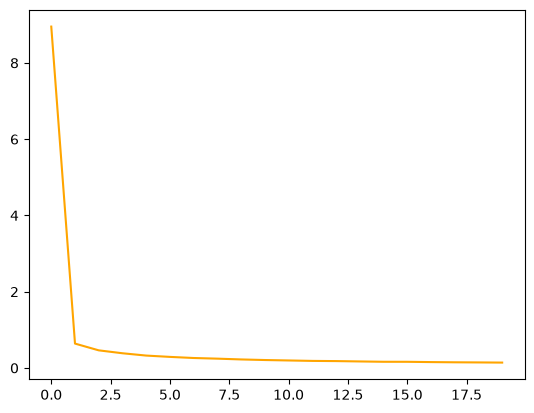

In [93]:
opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

loss = []
for i in range(20):
    l = train_epoch(model, train_dl)
    loss.append(l)
    print(l, validate_epoch(model, valid_dl))

plt.plot(loss, label="train", color="orange")
plt.show()